# Eksplorasi Data - Kabupaten Bangkalan

Eksplorasi Data adalah tahap untuk melihat, memvisualisasikan, dan
memeriksa kualitas data yang telah diperoleh pada tahap Data
Understanding, sebelum data diolah lebih lanjut pada tahap analisis
utama. Bagian ini mencakup peta interaktif wilayah, statistik deskriptif,
pemeriksaan missing values, dan deteksi outlier awal.

## 1. Peta Interaktif Wilayah Bangkalan

Peta berikut menampilkan bounding box AOI, titik pusat, serta beberapa
titik acuan kontekstual, yaitu akses Suramadu dan area pesisir Klampis,
yang relevan sebagai potensi sumber emisi. Peta mendukung dua basemap,
yaitu peta jalan dan citra satelit, yang dapat dipilih melalui kontrol
layer di kanan atas peta.

In [1]:
import folium
from folium.plugins import Fullscreen, MeasureControl, MiniMap

bbox = {"west": 112.671, "east": 113.116, "south": -7.227, "north": -6.848}
center = ((bbox["south"] + bbox["north"]) / 2, (bbox["west"] + bbox["east"]) / 2)

landmarks = [
    {"name": "Pusat Kota Bangkalan", "lat": -7.0392, "lon": 112.7487,
     "desc": "Pusat pemerintahan Kabupaten Bangkalan."},
    {"name": "Jembatan Suramadu (sisi Madura)", "lat": -7.1743, "lon": 112.7614,
     "desc": "Titik masuk arus kendaraan dari Surabaya, sumber emisi transportasi."},
    {"name": "Kecamatan Klampis (pesisir utara)", "lat": -6.9028, "lon": 112.9764,
     "desc": "Area pesisir dengan rencana fasilitas stockpile batu bara."},
]

m = folium.Map(location=center, zoom_start=10, tiles=None, control_scale=True)
folium.TileLayer("OpenStreetMap", name="Peta Jalan").add_to(m)
folium.TileLayer(
    tiles="https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}",
    attr="Esri, Maxar, Earthstar Geographics",
    name="Citra Satelit",
).add_to(m)

folium.Rectangle(
    bounds=[(bbox["south"], bbox["west"]), (bbox["north"], bbox["east"])],
    color="#d62728", weight=2.5, fill=True, fill_color="#d62728", fill_opacity=0.08,
    tooltip="Bounding box AOI Kabupaten Bangkalan",
).add_to(m)

folium.Marker(
    location=center, tooltip="Titik pusat AOI",
    icon=folium.Icon(color="red", icon="cloud", prefix="fa"),
).add_to(m)

for lm in landmarks:
    folium.Marker(
        location=(lm["lat"], lm["lon"]), tooltip=lm["name"],
        popup=f"<b>{lm['name']}</b><br>{lm['desc']}",
        icon=folium.Icon(color="blue", icon="info-sign"),
    ).add_to(m)

folium.LayerControl(collapsed=False).add_to(m)
MiniMap(toggle_display=True, position="bottomleft").add_to(m)
Fullscreen(position="topleft").add_to(m)
MeasureControl(primary_length_unit="kilometers").add_to(m)

m

## 2. Memuat Data Hasil Ekstraksi

In [2]:
import pandas as pd

pollutants = ["NO2", "CO", "SO2", "CH4"]
dataframes = {}

for pollutant in pollutants:
    df = pd.read_csv(f"../data/csv/bangkalan_{pollutant}.csv", parse_dates=["date"])
    df = df.sort_values("date").reset_index(drop=True)
    dataframes[pollutant] = df
    print(f"{pollutant}: {len(df)} baris, dari {df['date'].min().date()} sampai {df['date'].max().date()}")

NO2: 292 baris, dari 2025-08-24 sampai 2026-08-23
CO: 275 baris, dari 2025-08-24 sampai 2026-08-23
SO2: 322 baris, dari 2025-08-24 sampai 2026-08-23
CH4: 82 baris, dari 2025-08-24 sampai 2026-08-22


## 3. Statistik Deskriptif

Statistik deskriptif memberikan gambaran umum sebaran nilai tiap polutan,
seperti nilai rata rata, nilai minimum, nilai maksimum, dan sebaran
kuartil.

In [3]:
summary_rows = []
for pollutant, df in dataframes.items():
    desc = df[pollutant].describe()
    summary_rows.append({
        "polutan": pollutant,
        "jumlah_data": int(desc["count"]),
        "rata_rata": round(desc["mean"], 6),
        "std": round(desc["std"], 6),
        "minimum": round(desc["min"], 6),
        "maksimum": round(desc["max"], 6),
    })

summary_df = pd.DataFrame(summary_rows)
summary_df

,polutan,jumlah_data,rata_rata,std,minimum,maksimum
0,NO2,292,0.0,0.0,0.0,0.0
1,CO,275,0.0,0.0,0.0,0.0
2,SO2,322,0.0,0.0,0.0,0.0
3,CH4,82,0.0,0.0,0.0,0.0


## 4. Pemeriksaan Missing Values

Pemeriksaan dilakukan dengan melengkapi deret waktu agar memiliki baris
untuk setiap hari dalam rentang tanggal, karena sebagian hari mungkin
tidak memiliki data sama sekali, misalnya akibat tutupan awan atau tidak
adanya lintasan satelit pada hari tersebut.

In [4]:
for pollutant, df in dataframes.items():
    df_full = df.set_index("date").asfreq("D")
    n_missing = df_full[pollutant].isna().sum()
    pct_missing = 100 * n_missing / len(df_full)
    print(f"{pollutant}: {n_missing} dari {len(df_full)} hari kosong ({pct_missing:.1f} persen)")

NO2: 73 dari 365 hari kosong (20.0 persen)


CO: 90 dari 365 hari kosong (24.7 persen)
SO2: 43 dari 365 hari kosong (11.8 persen)
CH4: 282 dari 364 hari kosong (77.5 persen)


Pola dan besaran missing values ini menjadi catatan penting yang akan
ditangani, misalnya dengan interpolasi berbasis waktu, sebelum data
dipakai pada notebook analisis utama.

## 5. Deteksi Outlier Awal

Deteksi outlier awal dilakukan menggunakan algoritma **Isolation Forest**
dengan `contamination=0.05`, artinya diperkirakan sekitar 5 persen dari
data adalah outlier. Baris dengan nilai kosong dibuang terlebih dahulu
(`dropna`) agar tidak mengganggu proses pemodelan.

NO2: 0 outlier dari 292 data valid


CO: 0 outlier dari 275 data valid


SO2: 0 outlier dari 322 data valid


CH4: 0 outlier dari 82 data valid


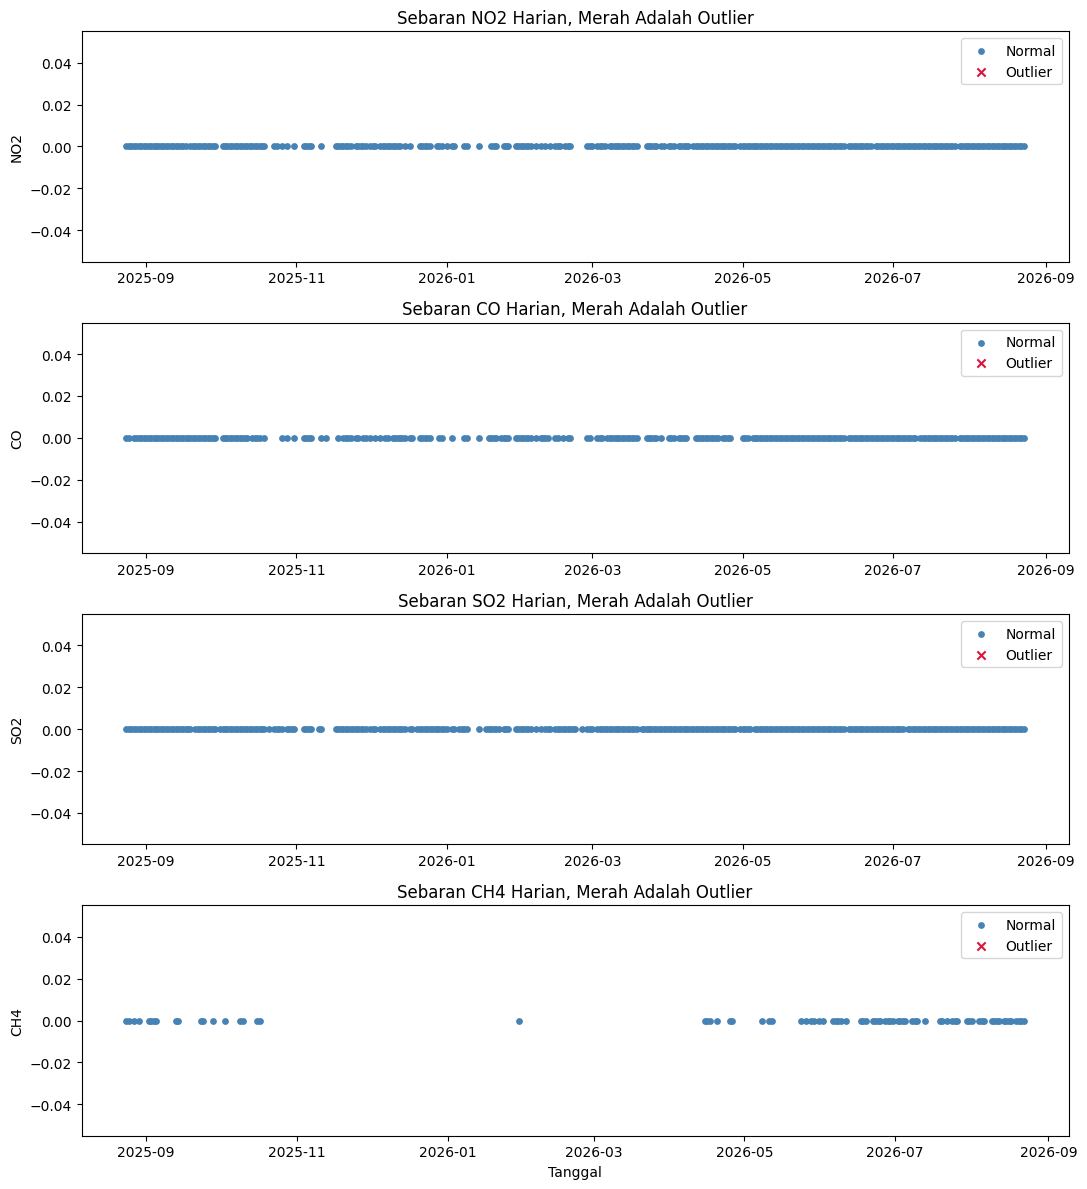

In [5]:
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

fig, axes = plt.subplots(len(pollutants), 1, figsize=(11, 3 * len(pollutants)), sharex=False)

for ax, pollutant in zip(axes, pollutants):
    df_clean = dataframes[pollutant].dropna(subset=[pollutant]).copy()

    model = IsolationForest(contamination=0.05, random_state=42)
    df_clean["outlier"] = model.fit_predict(df_clean[[pollutant]])

    normal = df_clean[df_clean["outlier"] == 1]
    outliers = df_clean[df_clean["outlier"] == -1]

    ax.scatter(normal["date"], normal[pollutant], color="steelblue", s=15, label="Normal")
    ax.scatter(outliers["date"], outliers[pollutant], color="crimson", s=35, marker="x", label="Outlier")
    ax.set_title(f"Sebaran {pollutant} Harian, Merah Adalah Outlier")
    ax.set_ylabel(pollutant)
    ax.legend(loc="upper right")

    print(f"{pollutant}: {len(outliers)} outlier dari {len(df_clean)} data valid")

axes[-1].set_xlabel("Tanggal")
plt.tight_layout()
plt.show()

## 6. Korelasi Antar Polutan

Sebagai eksplorasi tambahan, korelasi antar polutan dapat memberi
gambaran apakah polutan tertentu cenderung naik atau turun bersamaan,
yang dapat mengindikasikan sumber emisi yang berkaitan.

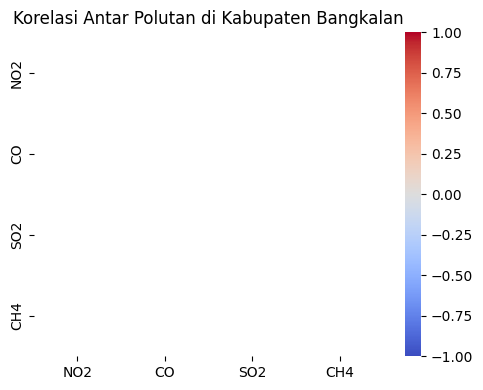

In [6]:
import seaborn as sns

merged = dataframes["NO2"][["date", "NO2"]].copy()
for pollutant in ["CO", "SO2", "CH4"]:
    merged = merged.merge(dataframes[pollutant][["date", pollutant]], on="date", how="outer")

corr = merged[pollutants].corr()

plt.figure(figsize=(5, 4))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Korelasi Antar Polutan di Kabupaten Bangkalan")
plt.tight_layout()
plt.show()

## 7. Temuan Sementara

Beberapa hal yang perlu diperhatikan berdasarkan eksplorasi di atas,
akan terisi secara otomatis dengan angka sebenarnya begitu data hasil
ekstraksi tersedia:

1. Proporsi missing values pada tiap polutan, sebagai dasar penentuan
   metode penanganan yang tepat pada tahap berikutnya.
2. Jumlah dan sebaran waktu titik outlier pada tiap polutan, sebagai
   dasar penyelidikan lebih lanjut, apakah outlier tersebut mencerminkan
   kejadian nyata atau gangguan data.
3. Pola korelasi antar polutan, sebagai dasar dugaan awal mengenai
   keterkaitan sumber emisi, misalnya NO2 dan CO yang sama sama berasal
   dari transportasi.

## 8. Kesimpulan

Eksplorasi data menunjukkan bahwa data hasil ekstraksi Sentinel-5P untuk
Kabupaten Bangkalan sudah berada dalam struktur yang siap diolah, yaitu
deret waktu harian per polutan dengan rentang tanggal yang jelas. Peta
interaktif memastikan bahwa cakupan wilayah AOI sudah sesuai dengan
konteks yang ingin dipantau, termasuk titik titik dengan potensi sumber
emisi seperti akses Suramadu dan pesisir Klampis. Pemeriksaan missing
values dan deteksi outlier awal pada bagian ini menjadi dasar bagi
penanganan data yang lebih menyeluruh, seperti interpolasi nilai kosong
dan investigasi outlier, yang akan dilakukan pada notebook
`2-analisis-bangkalan.ipynb`.